# arc.csv — Variance and Distribution by Experiment
This notebook loads `arc.csv` and shows per-experiment variance and distributions for each feature.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk', palette='deep')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 120,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
})


In [17]:
group = "6"
if group == "0":
    split_config_path = 'config/data-split-config/train_test_split_each_setup_80.json'
else:
    split_config_path = f'config/data-split-config/train_test_split_based_on_column_gp{group}.json'
from pathlib import Path
dir_path = Path("results") / "split_groups_distribution" / f"{group}"

dir_path.mkdir(parents=True, exist_ok=True)


In [18]:
df = pd.read_csv('data/processed/tube_geometry/arc.csv')
df.head()

,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,2,0.0,22.145797,21.453291,0.031511,-0.523025
1,2,1.0,22.147194,21.507501,0.029108,-0.468815
2,2,2.0,22.146727,21.587299,0.025456,-0.389017
3,2,3.0,22.145979,21.664488,0.021910,-0.311828
4,2,4.0,22.147433,21.720590,0.019423,-0.255727


In [19]:
# Identify numeric feature columns (excluding Experiment_ID and angle column)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
angle_col = 'Angle[degree]ORDistance[mm]'
feature_cols = [c for c in numeric_cols if c not in ['Experiment_ID', angle_col]]
feature_cols

['Secondary-axis [mm]',
 'Main-axis [mm]',
 'Out-of-roundness [-]',
 'Collapse [mm]']

In [23]:
import pandas as pd
import ast
from pathlib import Path

experiments_df = pd.read_csv( Path("data")/"ml"/"unique_bending_setups.csv")

unique_experiments = (
    experiments_df["Experiment_Number"]
    .apply(ast.literal_eval)
    .tolist()
)

In [24]:
'''
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

xcol = "Angle[degree]ORDistance[mm]"
GREY_AREA_COLOR = "grey"
GREY_AREA_ALPHA = 0.15

for experiment_group in unique_experiments:
    df_selected = df[df["Experiment_ID"].isin(experiment_group)].copy()

    fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axs = axs.ravel()  # flatten 2x2 into 1D list

    # Common x-grid for this group
    x_grid = np.sort(df_selected[xcol].dropna().unique())

    # Helper: interpolate y-values onto x_grid
    def interp_to_grid(dfg, feature):
        dfg = dfg[[xcol, feature]].dropna().sort_values(xcol)
        x = dfg[xcol].to_numpy()
        y = dfg[feature].to_numpy()

        if len(x) < 2:
            return np.full_like(x_grid, np.nan, dtype=float)

        y_interp = np.interp(x_grid, x, y)
        # mask values outside original range to avoid fake flat extrapolation
        y_interp[x_grid < x.min()] = np.nan
        y_interp[x_grid > x.max()] = np.nan
        return y_interp

    # Cache each experiment dataframe
    exp_groups = {exp_id: dfg for exp_id, dfg in df_selected.groupby("Experiment_ID")}

    for i, feature in enumerate(feature_cols):
        ax = axs[i]

        # ---- Baseline = mean curve across experiments (on the same x_grid) ----
        y_stack = []
        for exp_id, dfg in exp_groups.items():
            y_stack.append(interp_to_grid(dfg, feature))

        y_stack = np.vstack(y_stack)                 # (n_exps, len(x_grid))
        y_base = np.nanmean(y_stack, axis=0)         # baseline mean curve

        # Plot baseline (optional)
        ax.plot(x_grid, y_base, linewidth=2, label="Baseline (mean)")

        # ---- Plot each exp + grey shaded area between exp and baseline ----
        for exp_id, dfg in exp_groups.items():
            y_exp = interp_to_grid(dfg, feature)

            mask = np.isfinite(y_exp) & np.isfinite(y_base)
            ax.plot(x_grid, y_exp, label=f"Exp {exp_id}")

            ax.fill_between(
                x_grid[mask],
                y_exp[mask],
                y_base[mask],
                color=GREY_AREA_COLOR,
                alpha=GREY_AREA_ALPHA,
                linewidth=0
            )

        ax.set_title(feature)
        ax.set_xlabel("Angle")
        ax.set_ylabel(feature)
        ax.grid(True)
        ax.legend(fontsize=8)

    plt.tight_layout()

    dir_path_variations = Path("results") / "split_groups_distribution" / "variations"
    dir_path_variations.mkdir(parents=True, exist_ok=True)

    file_path = dir_path_variations / f"variation_{experiment_group}.pdf"
    plt.savefig(file_path, dpi=150, bbox_inches="tight")
'''

'\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom pathlib import Path\n\nxcol = "Angle[degree]ORDistance[mm]"\nGREY_AREA_COLOR = "grey"\nGREY_AREA_ALPHA = 0.15\n\nfor experiment_group in unique_experiments:\n    df_selected = df[df["Experiment_ID"].isin(experiment_group)].copy()\n\n    fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)\n    axs = axs.ravel()  # flatten 2x2 into 1D list\n\n    # Common x-grid for this group\n    x_grid = np.sort(df_selected[xcol].dropna().unique())\n\n    # Helper: interpolate y-values onto x_grid\n    def interp_to_grid(dfg, feature):\n        dfg = dfg[[xcol, feature]].dropna().sort_values(xcol)\n        x = dfg[xcol].to_numpy()\n        y = dfg[feature].to_numpy()\n\n        if len(x) < 2:\n            return np.full_like(x_grid, np.nan, dtype=float)\n\n        y_interp = np.interp(x_grid, x, y)\n        # mask values outside original range to avoid fake flat extrapolation\n        y_interp[x_grid < x.min()] = np.nan\n        y_in

## Split helpers (set JSON path once and reuse)

In [25]:
import json

# Set your split config path here

def plot_train_test_distributions(split_config_path, df, feature_cols, experiment_col='Experiment_ID'):
    train_ids, test_ids = load_split_ids(split_config_path)
    df_train = df[df[experiment_col].isin(train_ids)].copy()
    df_test = df[df[experiment_col].isin(test_ids)].copy()

    def plot_distributions(title, data, part):
        n = len(feature_cols)
        cols = 2
        rows = int(np.ceil(n / cols))
        plt.figure(figsize=(12, 4 * rows))
        for i, col in enumerate(feature_cols, 1):
            ax = plt.subplot(rows, cols, i)
            sns.histplot(data[col], kde=True, ax=ax, bins=30, color=sns.color_palette()[0], alpha=0.7)
            ax.set_title(f'{title}: {col}')
            ax.grid(True, alpha=0.2)
        sns.despine()
        plt.tight_layout()
        file_path = dir_path / f'distribution-{part}.pdf'
        plt.savefig(file_path, dpi=150, bbox_inches="tight")
        plt.close()
        plt.show()

    plot_distributions('Train distribution', df_train, "train")
    plot_distributions('Test distribution', df_test, "test")


def load_split_ids(split_config_path):
    with open(split_config_path, 'r') as f:
        split_cfg = json.load(f)

    train_ids = sorted({eid for group in split_cfg['train_groups'] for eid in group})
    test_ids = sorted({eid for group in split_cfg['test_groups'] for eid in group})

    return train_ids, test_ids


def plot_mean_std_by_angle_train_test(
    split_config_path,
    df,
    feature_cols,
    angle_col='Angle[degree]ORDistance[mm]',
    experiment_col='Experiment_ID'
):
    train_ids, test_ids = load_split_ids(split_config_path)

    df_train = df[df[experiment_col].isin(train_ids)].copy()
    df_test = df[df[experiment_col].isin(test_ids)].copy()

    if angle_col not in df.columns:
        print(f'Angle column not found: {angle_col}')
        return

    mean_std_by_angle_train = df_train.groupby(angle_col)[feature_cols].agg(['mean', 'std'])
    mean_std_by_angle_test = df_test.groupby(angle_col)[feature_cols].agg(['mean', 'std'])

    display(mean_std_by_angle_train)
    display(mean_std_by_angle_test)

    train_color = sns.color_palette('deep')[0]
    test_color = sns.color_palette('deep')[2]

    for col in feature_cols:
        stats_train = df_train.groupby(angle_col)[col].agg(['mean', 'std']).reset_index()
        stats_test = df_test.groupby(angle_col)[col].agg(['mean', 'std']).reset_index()

        fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey='row')

        # ---------------- TOP ROW: MEAN ----------------

        # Train
        axes[0, 0].scatter(
            df_train[angle_col], df_train[col],
            color=train_color, s=12, alpha=0.3
        )
        axes[0, 0].plot(
            stats_train[angle_col], stats_train['mean'],
            color=train_color, linewidth=2
        )
        axes[0, 0].set_title("Train")
        axes[0, 0].grid(True, alpha=0.2)

        # Test
        axes[0, 1].scatter(
            df_test[angle_col], df_test[col],
            color=test_color, s=12, alpha=0.3
        )
        axes[0, 1].plot(
            stats_test[angle_col], stats_test['mean'],
            color=test_color, linewidth=2
        )
        axes[0, 1].set_title("Test")
        axes[0, 1].grid(True, alpha=0.2)

        # Train vs Test
        axes[0, 2].plot(
            stats_train[angle_col], stats_train['mean'],
            color=train_color, label='Train', linewidth=2
        )
        axes[0, 2].plot(
            stats_test[angle_col], stats_test['mean'],
            color=test_color, label='Test', linewidth=2
        )
        axes[0, 2].set_title("Train vs Test")
        axes[0, 2].grid(True, alpha=0.2)
        axes[0, 2].legend()

        # ---------------- BOTTOM ROW: STD BAND ----------------

        # Train
        axes[1, 0].plot(
            stats_train[angle_col], stats_train['mean'],
            color=train_color, linewidth=2
        )
        axes[1, 0].fill_between(
            stats_train[angle_col],
            stats_train['mean'] - stats_train['std'],
            stats_train['mean'] + stats_train['std'],
            color=train_color,
            alpha=0.2
        )
        axes[1, 0].set_xlabel("Angle")
        axes[1, 0].grid(True, alpha=0.2)

        # Test
        axes[1, 1].plot(
            stats_test[angle_col], stats_test['mean'],
            color=test_color, linewidth=2
        )
        axes[1, 1].fill_between(
            stats_test[angle_col],
            stats_test['mean'] - stats_test['std'],
            stats_test['mean'] + stats_test['std'],
            color=test_color,
            alpha=0.2
        )
        axes[1, 1].set_xlabel("Angle")
        axes[1, 1].grid(True, alpha=0.2)

        # Train vs Test
        axes[1, 2].plot(
            stats_train[angle_col], stats_train['mean'],
            color=train_color, label='Train', linewidth=2
        )
        axes[1, 2].fill_between(
            stats_train[angle_col],
            stats_train['mean'] - stats_train['std'],
            stats_train['mean'] + stats_train['std'],
            color=train_color,
            alpha=0.2
        )
        axes[1, 2].plot(
            stats_test[angle_col], stats_test['mean'],
            color=test_color, label='Test', linewidth=2
        )
        axes[1, 2].fill_between(
            stats_test[angle_col],
            stats_test['mean'] - stats_test['std'],
            stats_test['mean'] + stats_test['std'],
            color=test_color,
            alpha=0.2
        )
        axes[1, 2].set_xlabel("Angle")
        axes[1, 2].grid(True, alpha=0.2)
        axes[1, 2].legend()

        fig.text(-0.01, 0.5, col, rotation=90, va='center', ha='center')
        fig.tight_layout(rect=[-.01, 0, 1, 1])

        file_path = dir_path / f'mean-std-by-angle-train-test_{col}.pdf'
        fig.savefig(file_path, dpi=150, bbox_inches='tight')
        plt.show()

## Variance per experiment (by feature)

In [26]:
df

,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,2,0.00,22.145797,21.453291,0.031511,-0.523025
1,2,1.00,22.147194,21.507501,0.029108,-0.468815
2,2,2.00,22.146727,21.587299,0.025456,-0.389017
3,2,3.00,22.145979,21.664488,0.021910,-0.311828
4,2,4.00,22.147433,21.720590,0.019423,-0.255727
...,...,...,...,...,...,...
14558,318,41.00,22.337259,21.529122,0.036548,-0.582226
14559,318,42.00,22.336641,21.527574,0.036591,-0.583774
14560,318,43.00,22.336513,21.530579,0.036449,-0.580770
14561,318,44.00,22.336929,21.538760,0.036098,-0.572589


In [27]:
var_by_experiment = df.groupby('Experiment_ID')[feature_cols].var()

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ipywidgets as widgets
from IPython.display import display

feature_selector = widgets.SelectMultiple(
    options=feature_cols,
    value=[feature_cols[0]],
    description="Features:",
    layout=widgets.Layout(width="50%", height="200px")
)

bins_slider = widgets.IntSlider(
    value=30, min=5, max=100, step=5,
    description="Bins:"
)

def plot_multi_hist(features, bins):
    if len(features) == 0:
        print("⚠️ Select at least one feature")
        return
    
    n = len(features)
    cols = 2
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(12, 4 * rows))

    for i, col in enumerate(features, 1):
        ax = plt.subplot(rows, cols, i)
        sns.histplot(df[col], kde=True, ax=ax, bins=bins, alpha=0.7)
        ax.set_title(f"Distribution: {col}")
        ax.grid(True, alpha=0.2)

    sns.despine()
    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(
    plot_multi_hist,
    {"features": feature_selector, "bins": bins_slider}
)

display(widgets.VBox([feature_selector, bins_slider]), out)


Output()

## Distributions (train/test)

In [29]:
# Distributions for train and test splits
plot_train_test_distributions(split_config_path, df, feature_cols)

## Mean and std by angle (train/test split)

Secondary-axis [mm]           Main-axis [mm]  \
                                           mean       std           mean   
Angle[degree]ORDistance[mm]                                                
0.00                                  22.282115  0.088911      21.650428   
1.00                                  22.276456  0.088011      21.608571   
2.00                                  22.271048  0.086268      21.571956   
3.00                                  22.265530  0.084418      21.537827   
4.00                                  22.260247  0.083100      21.505322   
...                                         ...       ...            ...   
44.94                                 22.096729       NaN      21.438947   
44.97                                 22.110655       NaN      21.446238   
45.00                                 22.131071  0.016645      21.478229   
45.01                                 22.119374       NaN      21.477768   
45.28                                 22.145007       NaN      21.479878   

                                      Out-of-roundness [-]            \
                                  std                 mean       std   
Angle[degree]ORDistance[mm]                                            
0.00                         0.305496             0.028647  0.014340   
1.00                         0.304831             0.030289  0.014703   
2.00                         0.303026             0.031704  0.015033   
3.00                         0.301075             0.033001  0.015310   
4.00                         0.298901             0.034236  0.015493   
...                               ...                  ...       ...   
44.94                             NaN             0.029857       NaN   
44.97                             NaN             0.030150       NaN   
45.00                        0.000842             0.029601  0.000705   
45.01                             NaN             0.029100       NaN   
45.28                             NaN             0.030150       NaN   

                            Collapse [mm]            
                                     mean       std  
Angle[degree]ORDistance[mm]                          
0.00                            -0.399705  0.302827  
1.00                            -0.441562  0.302487  
2.00                            -0.478177  0.301147  
3.00                            -0.512306  0.299695  
4.00                            -0.544811  0.298010  
...                                   ...       ...  
44.94                           -0.592465       NaN  
44.97                           -0.590859       NaN  
45.00                           -0.576444  0.007814  
45.01                           -0.570783       NaN  
45.28                           -0.580915       NaN  

[85 rows x 8 columns]

Secondary-axis [mm]           Main-axis [mm]  \
                                           mean       std           mean   
Angle[degree]ORDistance[mm]                                                
0.00                                  22.189058  0.044494      22.105017   
1.00                                  22.178018  0.044707      22.084427   
2.00                                  22.167536  0.044504      22.047375   
3.00                                  22.157624  0.045088      21.992701   
4.00                                  22.148281  0.045788      21.925966   
...                                         ...       ...            ...   
45.36                                 22.162477       NaN      21.637548   
45.37                                 22.088139       NaN      21.468084   
45.38                                 22.113138  0.063407      21.571097   
45.39                                 22.127244       NaN      21.597299   
45.42                                 22.118402       NaN      21.563877   

                                      Out-of-roundness [-]            \
                                  std                 mean       std   
Angle[degree]ORDistance[mm]                                            
0.00                         0.269878             0.003810  0.011699   
1.00                         0.255945             0.004243  0.011127   
2.00                         0.231449             0.005448  0.010073   
3.00                         0.200424             0.007478  0.008696   
4.00                         0.165089             0.010080  0.007093   
...                               ...                  ...       ...   
45.36                             NaN             0.023778       NaN   
45.37                             NaN             0.028121       NaN   
45.38                        0.030934             0.024570  0.001420   
45.39                             NaN             0.024014       NaN   
45.42                             NaN             0.025145       NaN   

                            Collapse [mm]            
                                     mean       std  
Angle[degree]ORDistance[mm]                          
0.00                             0.050049  0.269191  
1.00                             0.029458  0.254971  
2.00                            -0.007594  0.230043  
3.00                            -0.062267  0.198380  
4.00                            -0.129003  0.162130  
...                                   ...       ...  
45.36                           -0.438489       NaN  
45.37                           -0.581361       NaN  
45.38                           -0.489073  0.015571  
45.39                           -0.471240       NaN  
45.42                           -0.489674       NaN  

[71 rows x 8 columns]

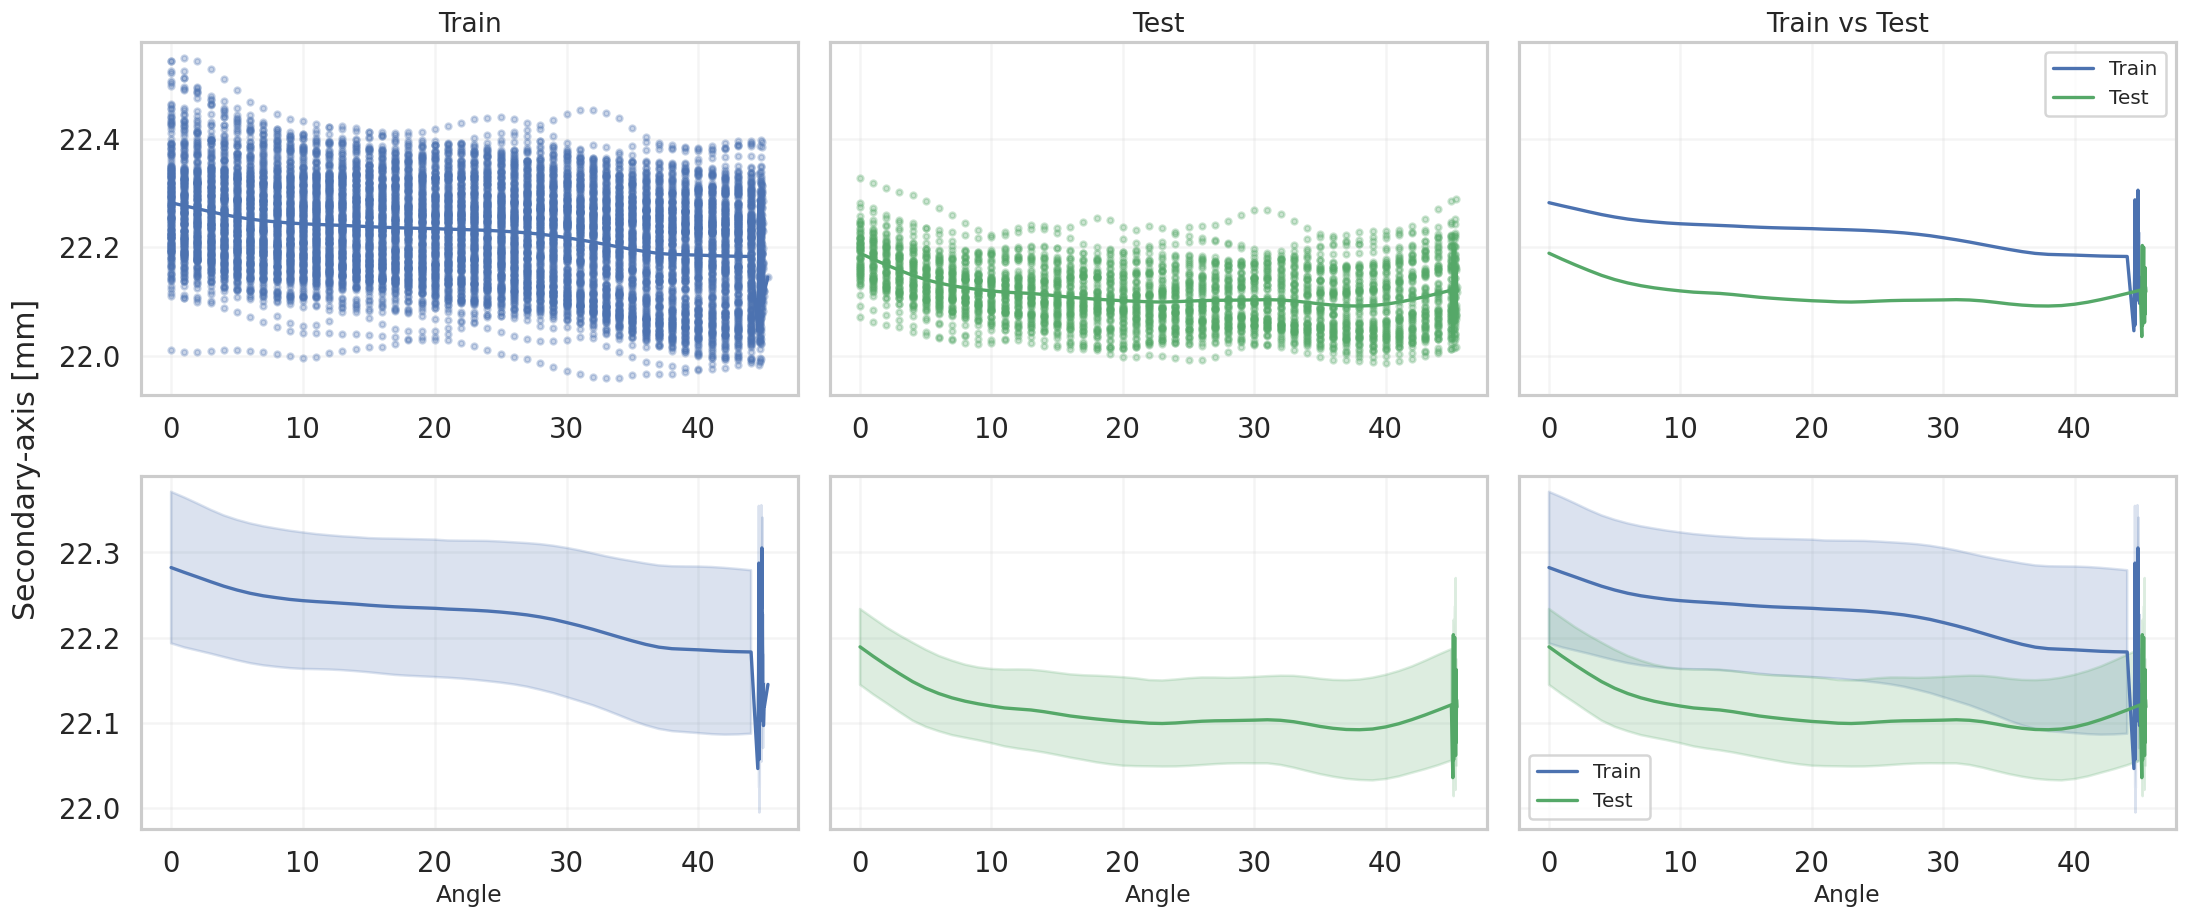

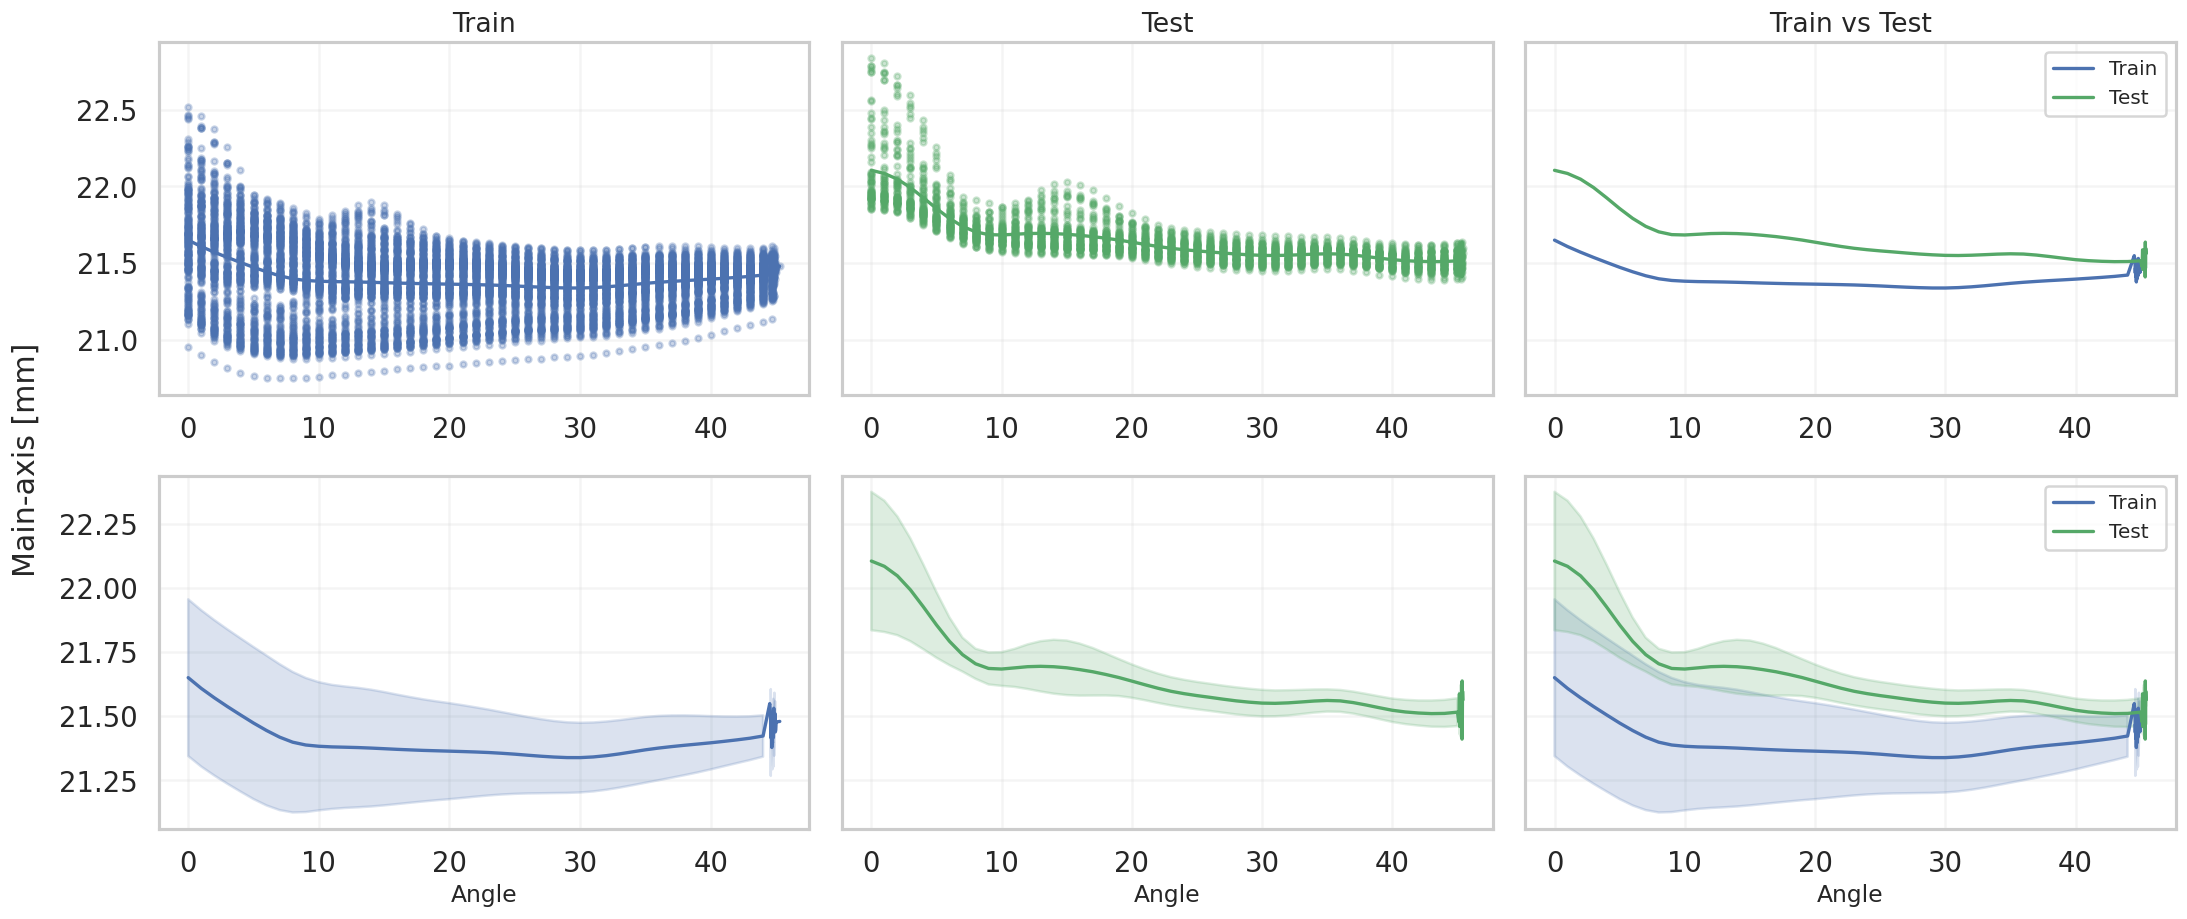

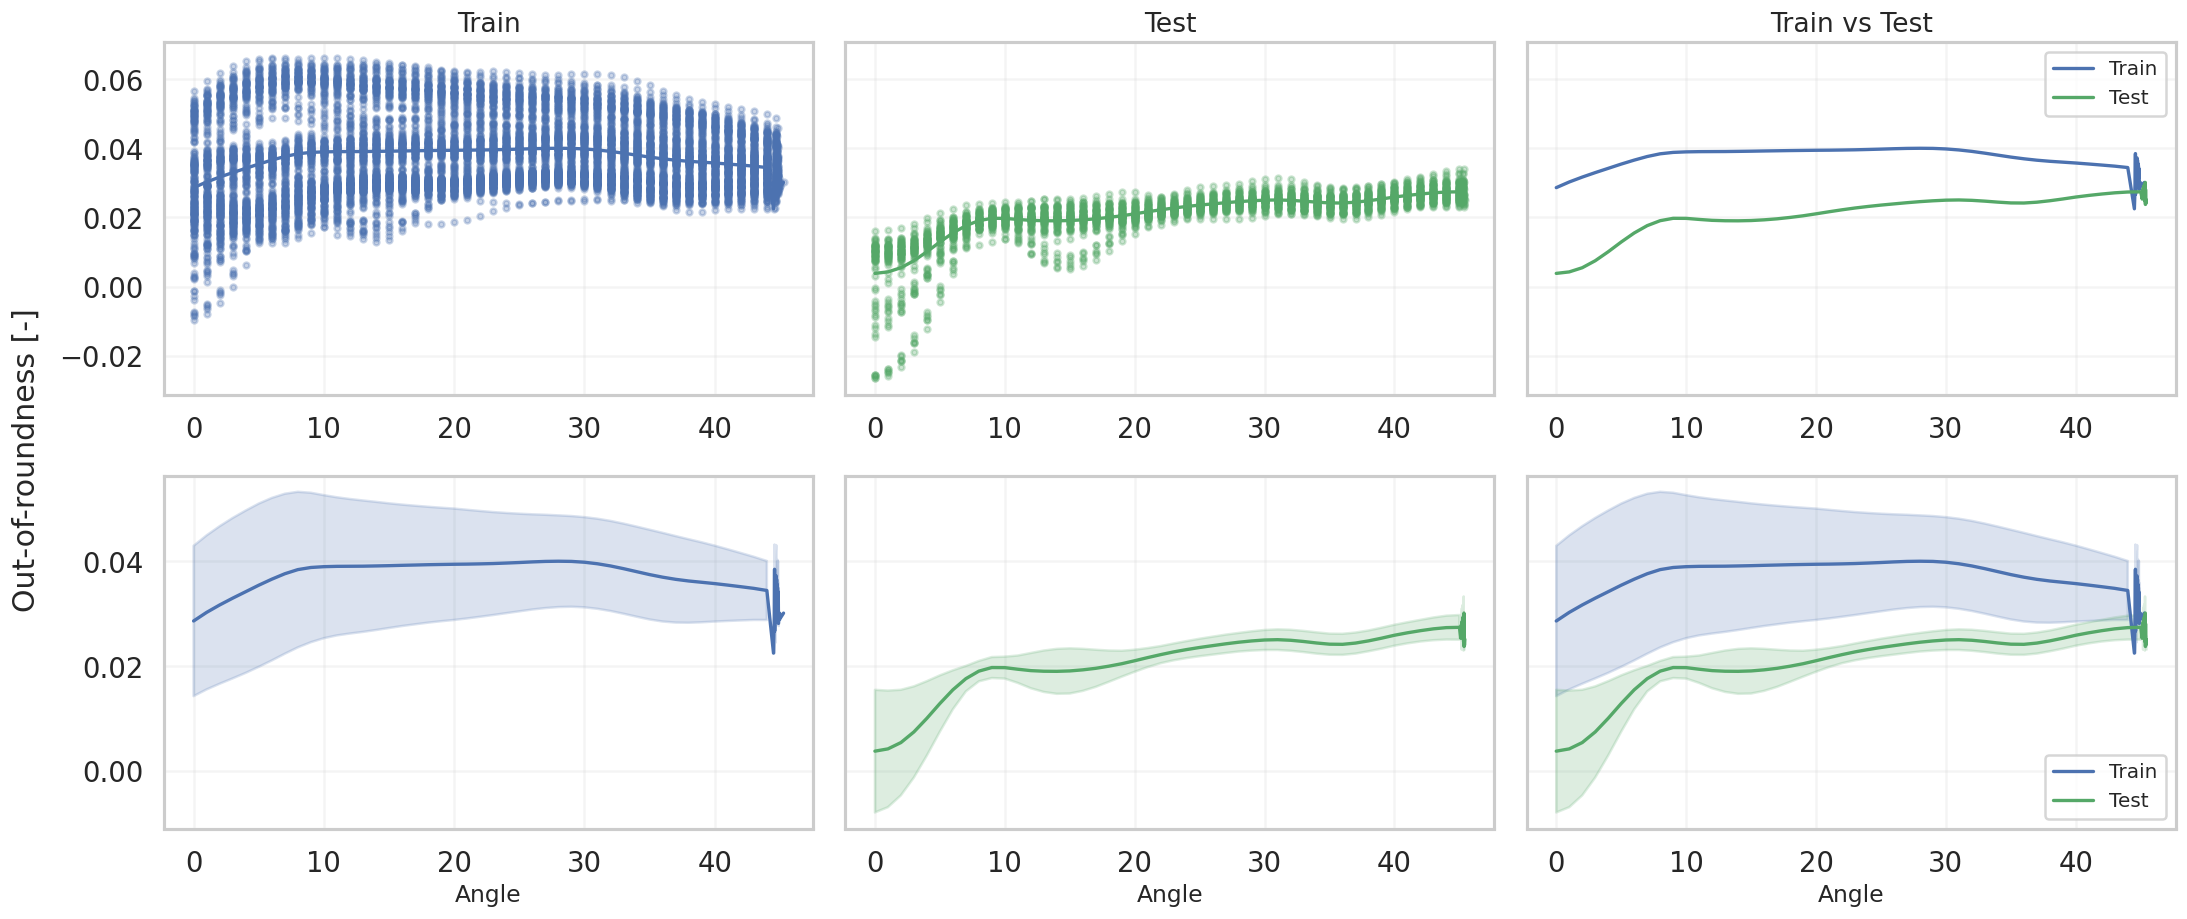

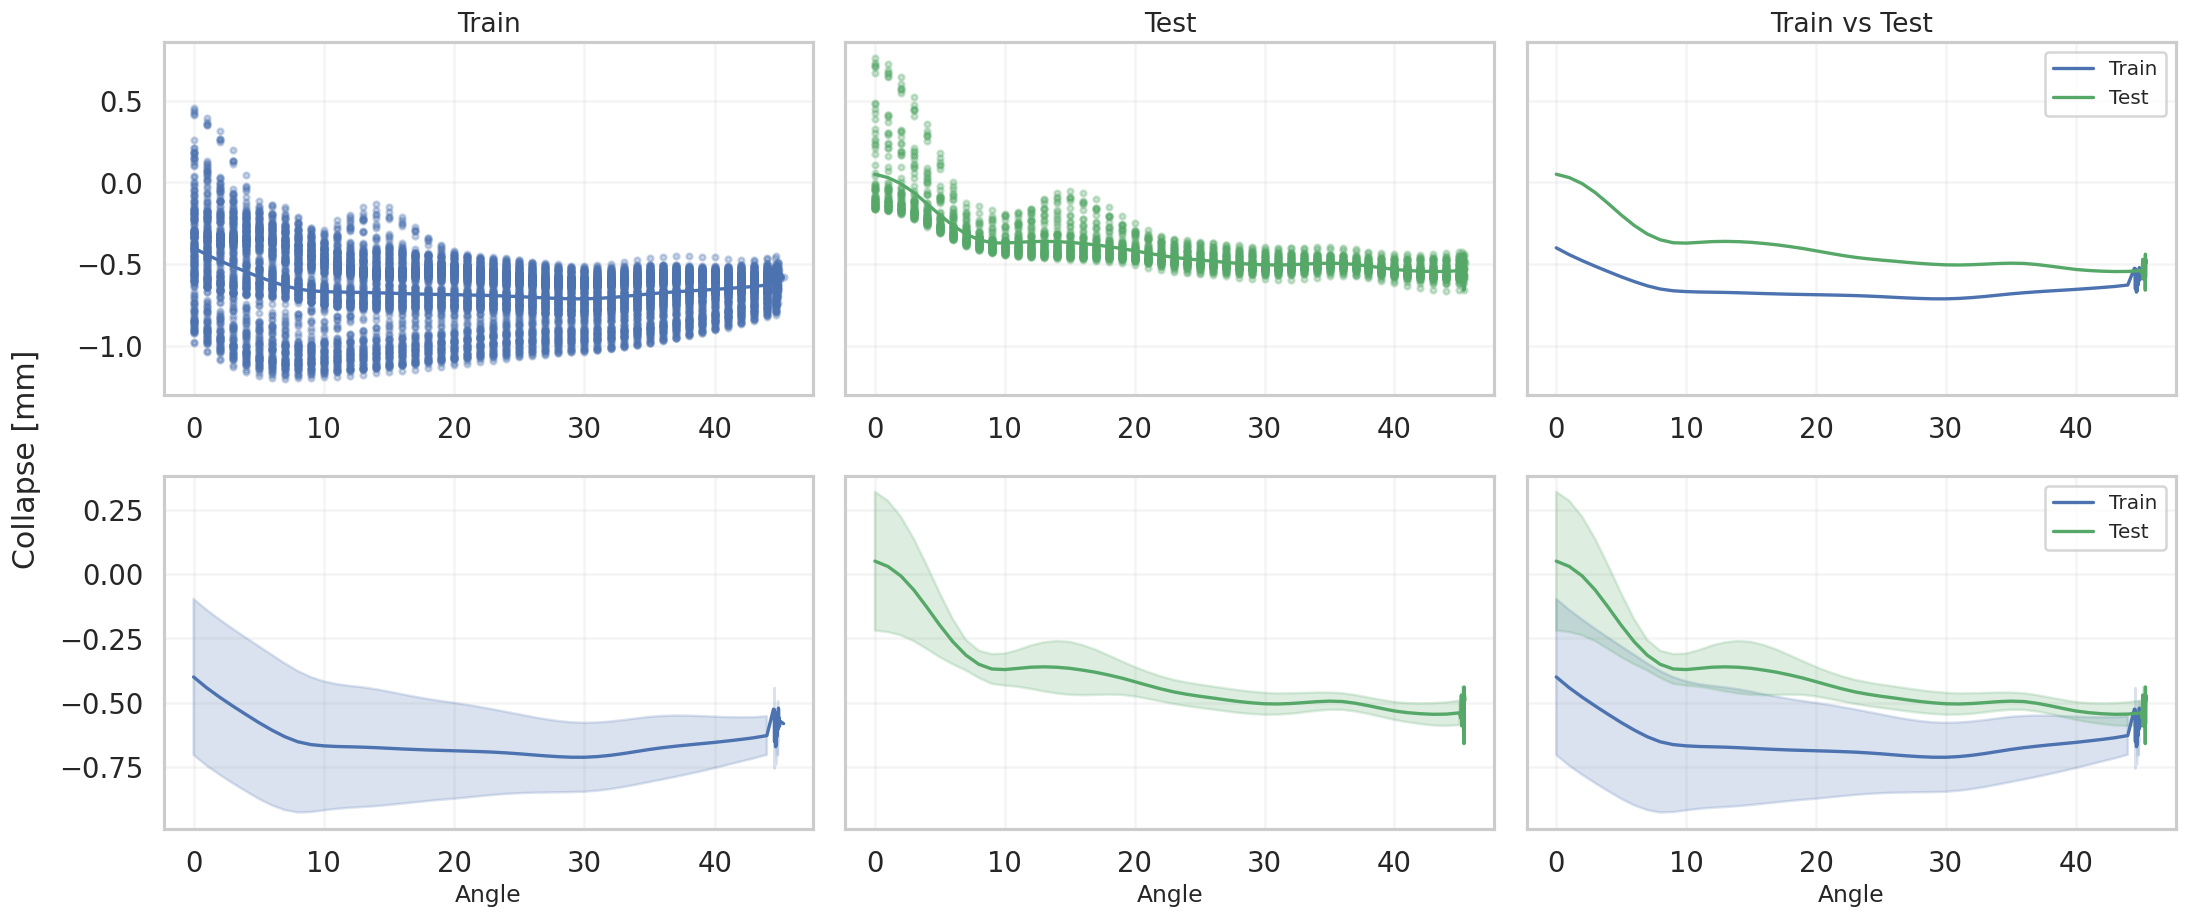

In [30]:
# Mean/std by angle for train and test splits
plot_mean_std_by_angle_train_test(split_config_path, df, feature_cols)